# CNN Model

### Import packages and load data

In [129]:
%reload_ext autoreload
%autoreload 2
%aimport -numpy, -pandas, -matplotlib

import sys
import yaml
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import matplotlib.pyplot as plt
# use same font as latex
# plt.rc('text', usetex=True)

plt.rc('font', family='serif')

import pandas as pd
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
from dataset.utils.fungi_vis import FungiTasticVis

from types import SimpleNamespace
# import SimpleNamespace

#  fix random seeds for reproducibility
import random
import numpy as np
from PIL import Image, ImageOps
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
from collections import Counter
import cv2
random.seed(0)
np.random.seed(0)

In [30]:
valset = FungiTasticVis(
        root=f"{os.getcwd()}/dataset/FungiTastic/",
        split='val',
        size='300',
        task='open',
        data_subset='Mini',
        transform=None,
)

trainset = FungiTasticVis(
        root=f"{os.getcwd()}/dataset/FungiTastic/",
        split='train',
        size='300',
        task='closed',
        data_subset='Mini',
        transform=None,
)

testset = FungiTasticVis(
        root=f"{os.getcwd()}/dataset/FungiTastic/",
        split='test',
        size='300',
        task='closed',
        data_subset='Mini',
        transform=None,
)

### Data preprocessing

In this code chunk, I am defining functions that first extract the training paths and labels from the datasets loaded above, and then define a function that creates a tf.dataset so that not all images need to be loaded into memory at once (will slow computer or crash).

In [119]:
from tqdm import tqdm

def extract_paths_and_labels(ds, expect_labels=True):
    paths, labels = [], []
    for i in tqdm(range(len(ds)), desc="Indexing"):
        _, y, p = ds[i]            # (PIL_image, label, path)
        paths.append(str(p))
        if expect_labels:
            if y is None:
                raise ValueError("Dataset has unlabeled samples but expect_labels=True.")
            labels.append(int(y))  # adjust if your labels are strings
    return (paths, labels) if expect_labels else (paths, None)

train_paths, train_labels = extract_paths_and_labels(trainset, expect_labels=True)
val_paths,   val_labels   = extract_paths_and_labels(valset,   expect_labels=True)
test_paths,  _            = extract_paths_and_labels(testset,  expect_labels=False)  # labels are None

Indexing: 100%|██████████| 10738/10738 [00:19<00:00, 564.86it/s]


In [ ]:
autotune   = tf.data.AUTOTUNE
batch_size      = 64
h, w = 224, 224

def decode_and_resize_from_path(path):
    bytes_ = tf.io.read_file(path)
    img = tf.image.decode_image(bytes_, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [h, w],
                          method=tf.image.ResizeMethod.LANCZOS5)  # or BICUBIC
    img = tf.clip_by_value(img, 0.0, 255.0)    # <-- keep within range
    img = tf.cast(img, tf.float32) / 255.0
    return img

In [ ]:
def make_supervised_ds(paths, labels, training=True, shuffle_buf=10_000):
    """
    This function creates a tf dataset, which loads and preprocesses the data in batches of 64 images. It resizes them to be (224,224) images,
    randomly shuffles the data, and also randomly flips images horizontally.
    """
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(shuffle_buf, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: (decode_and_resize_from_path(p), tf.cast(y, tf.int32)),
                num_parallel_calls=autotune)
    ds = ds.ignore_errors()

    if training:
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y),
                    num_parallel_calls=autotune)
    ds = ds.batch(batch_size, drop_remainder=training).prefetch(autotune)

    opts = tf.data.Options(); opts.experimental_deterministic = False
    return ds.with_options(opts)

train_ds = make_supervised_ds(train_paths, train_labels, training=True)
val_ds   = make_supervised_ds(val_paths,   val_labels,   training=False)

In [64]:
#Sanity check
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("dtype:", images.dtype)
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (64, 224, 224, 3)
Label batch shape: (64,)
dtype: <dtype: 'float32'>
Min pixel value: 0.0
Max pixel value: 1.0


2025-11-09 16:40:46.016561: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Baseline Model: Majority Class Predictor

In [115]:
majority_label = Counter(train_labels).most_common(1)[0][0]
print("Majority class:", majority_label)

Majority class: 83


In [128]:
def majority_accuracy(dataset, majority_label):
    total = 0
    correct = 0
    for i, (_, y) in enumerate(dataset):
        y_np = y.numpy()
        pred = np.full_like(y_np, fill_value=majority_label)
        correct += (pred == y_np).sum()
        total += y_np.size
    return correct / total

maj_train_acc = majority_accuracy(train_ds, majority_label)
maj_val_acc   = majority_accuracy(val_ds,   majority_label)
print(f"Majority baseline — train = {maj_train_acc:.3f}, val={maj_val_acc:.3f}")

2025-11-09 17:14:24.260383: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Majority baseline — train = 0.035, val=0.026


2025-11-09 17:14:30.162089: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### CNN baseline - no metadata

In [132]:
n_classes = len(np.unique(train_labels))

# define an instance of the early_stopping class
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='accuracy', 
verbose=1,
patience=5,
mode='max',
restore_best_weights=True)

Model: "baseline_cnn_multi"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 224, 224, 12)   │           588 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 112, 112, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 12)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 215)            │         2,795 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,383 (13.21 KB)

 Trainable params: 3,383 (13.21 KB)

 Non-trainable params: 0 (0.00 B)

...

2025-11-09 17:42:32.382203: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2025-11-09 17:42:32.382224: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8283613947480538547
2025-11-09 17:42:32.382227: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 7196660349145683503
2025-11-09 17:42:32.382235: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


731/731 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.0491 - loss: 4.7056

2025-11-09 17:43:28.863593: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/adam/Add_4/_28]]
2025-11-09 17:43:28.863611: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 7011370649965986072
2025-11-09 17:43:28.863615: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 11230952373735678690
2025-11-09 17:43:28.863619: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 15841523053490852702
2025-11-09 17:43:28.863623: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-11-09 17:43:28.863630: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 601805450

731/731 ━━━━━━━━━━━━━━━━━━━━ 63s 86ms/step - accuracy: 0.0505 - loss: 4.7110 - val_accuracy: 0.0751 - val_loss: 4.5025


2025-11-09 17:43:35.458315: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-11-09 17:43:35.458330: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2025-11-09 17:43:35.458346: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 5643512867312272865
2025-11-09 17:43:35.458352: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8283613947480538547
2025-11-09 17:43:35.458355: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 7196660349145683503
2025-11-09 17:43:35.458359: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 10412635034643904572
2025-11-09

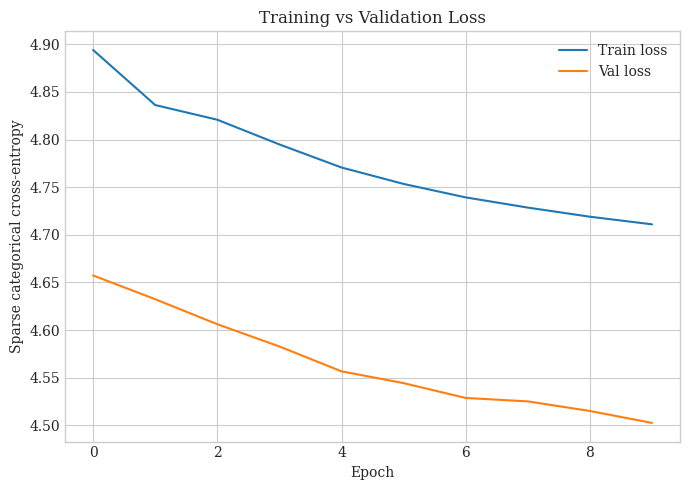

2025-11-09 17:44:10.378331: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-11-09 17:44:10.378366: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2025-11-09 17:44:10.378379: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 5643512867312272865
2025-11-09 17:44:10.378429: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8283613947480538547
2025-11-09 17:44:10.378450: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 7196660349145683503
2025-11-09 17:44:10.378489: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 10412635034643904572
2025-11-09

Train accuracy: 0.0513 | Val accuracy: 0.0751


2025-11-09 17:44:18.244115: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-11-09 17:44:18.244132: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2025-11-09 17:44:18.244139: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 5643512867312272865
2025-11-09 17:44:18.244143: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8283613947480538547
2025-11-09 17:44:18.244147: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 7196660349145683503
2025-11-09 17:44:18.244152: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 10412635034643904572
2025-11-09

In [135]:
tf.random.set_seed(1234)
np.random.seed(1234)

baseline_cnn = tf.keras.Sequential(name="baseline_cnn_multi")
baseline_cnn.add(tf.keras.layers.Conv2D(
    filters=12, kernel_size=(4,4), strides=(1,1), padding='same',
    activation='relu', name='conv_1', input_shape=(224,224,3)
))
baseline_cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))
baseline_cnn.add(tf.keras.layers.Dropout(rate=0.3))
baseline_cnn.add(tf.keras.layers.GlobalAveragePooling2D())
baseline_cnn.add(tf.keras.layers.Dense(n_classes, activation='softmax')) 

baseline_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),  
    metrics=['accuracy']
)

baseline_cnn.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

history = baseline_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping],
    verbose=1
)

plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Sparse categorical cross-entropy')
plt.title('Training vs Validation Loss'); plt.legend(); plt.tight_layout(); plt.show()

train_loss, train_acc = baseline_cnn.evaluate(train_ds, verbose=0)
val_loss,   val_acc   = baseline_cnn.evaluate(val_ds,   verbose=0)
print(f"Train accuracy: {train_acc:.4f} | Val accuracy: {val_acc:.4f}")